# Predicting the price of used cars

##### The main theme of this project is to  predict used cars market value can help both buyers and sellers ...



## import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

sns.set_palette("GnBu_d")
sns.set_style("whitegrid")


from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/My Drive/Colab Notebooks/Data science CS21B2023/'

Mounted at /content/drive


## 1.Load the data

In [2]:
car_data = pd.read_csv(path+"car_price_data1.csv")
car_data

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
...,...,...,...,...,...,...,...,...,...
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,S 350
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,535
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985,520
4343,Toyota,14200.0,sedan,31,NaN,Petrol,yes,2014,Corolla


In [3]:

car_data.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


## Preprocessing 

### Exploring descriptive stats of variables. ex: 25%,mean,median etc...

In [4]:
car_data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


In [5]:
# info of data
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4345 non-null   object 
 1   Price         4173 non-null   float64
 2   Body          4345 non-null   object 
 3   Mileage       4345 non-null   int64  
 4   EngineV       4195 non-null   float64
 5   Engine Type   4345 non-null   object 
 6   Registration  4345 non-null   object 
 7   Year          4345 non-null   int64  
 8   Model         4345 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 305.6+ KB


In [6]:
# Drop features which are not required for building a model

ndf = car_data.drop(labels="Model",axis=1)
ndf

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011
...,...,...,...,...,...,...,...,...
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985
4343,Toyota,14200.0,sedan,31,NaN,Petrol,yes,2014


In [7]:
# Check for missing values in new data frame

ndf.isna().sum()

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
dtype: int64

In [8]:
# Drop the Nan values because they are not useful

ndf1 = ndf.dropna()
ndf1

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011
...,...,...,...,...,...,...,...,...
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985


In [9]:
# check whether there are NaN values
ndf1.isna().sum()

Brand           0
Price           0
Body            0
Mileage         0
EngineV         0
Engine Type     0
Registration    0
Year            0
dtype: int64

## DATA EXPLORATION

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


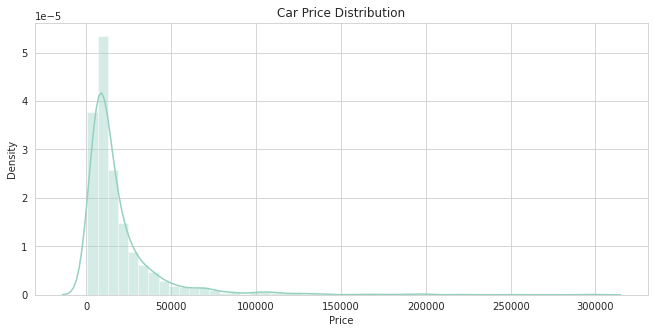

In [10]:
plt.figure(figsize=[11,5])
sns.distplot(ndf1['Price']);    # dist-density distribution
plt.title('Car Price Distribution');

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

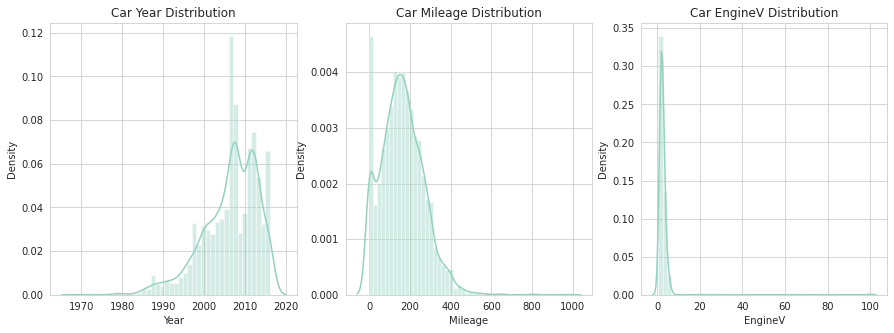

In [11]:
# car vs year

plt.figure(figsize=[15,5])
plt.subplot(1,3,1)
sns.distplot(ndf1['Year'])
plt.title('Car Year Distribution');

# car vs mileage
plt.subplot(1,3,2)
sns.distplot(ndf1['Mileage'])
plt.title('Car Mileage Distribution');

# car vs EngineV
plt.subplot(1,3,3)
sns.distplot(ndf1['EngineV'])
plt.title('Car EngineV Distribution');

## OUTLIERS

### About Price

In [12]:
x = ndf1['Price'].quantile(0.99)  #  99 th percentile


#  creating a new df, in which  all prices must be below the 99 percentile
ndf2 = ndf1[ndf1['Price']<x]
ndf2

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011
...,...,...,...,...,...,...,...,...
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985


/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


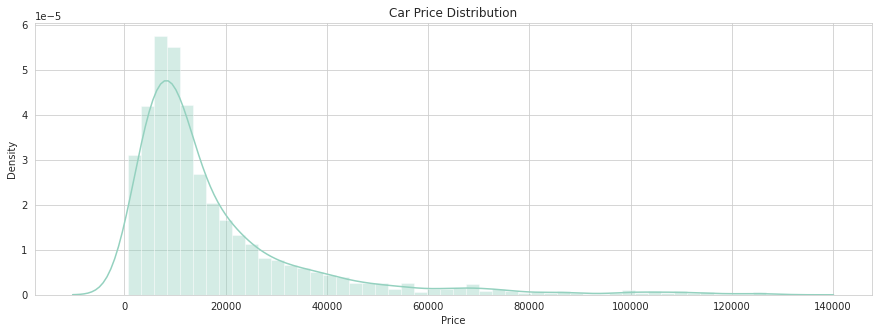

In [13]:
plt.figure(figsize=[15,5])
sns.distplot(ndf2["Price"])
plt.title("Car Price Distribution");

### About Mileage


/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


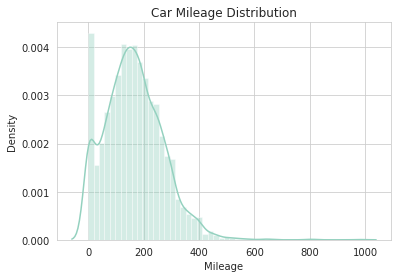

In [14]:
sns.distplot(ndf2["Mileage"])
plt.title("Car Mileage Distribution");

In [15]:
#  creating a new df, in which  Mileage values must be below the 99 percentile
y =  ndf1['Mileage'].quantile(0.99)

ndf3 = ndf1[ndf1['Mileage']<y]
ndf3

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011
...,...,...,...,...,...,...,...,...
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985


/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


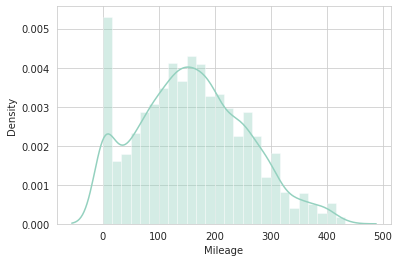

In [16]:
sns.distplot(ndf3['Mileage']);

### About Year




/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


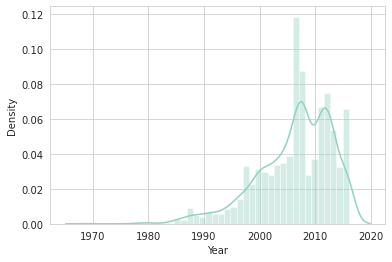

In [17]:
sns.distplot(ndf1['Year']);


In [18]:
z = ndf3['Year'].quantile(0.01)
ndf4 = ndf3[ndf3['Year']>z]
ndf4

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011
...,...,...,...,...,...,...,...,...
4338,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999


/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


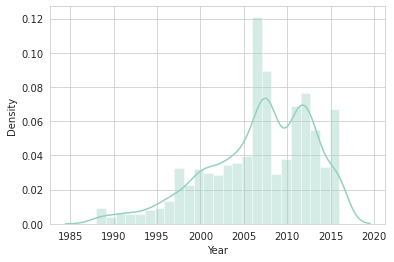

In [19]:
sns.distplot(ndf4['Year']);

### About Engine

In [20]:
ndf3


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011
...,...,...,...,...,...,...,...,...
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985


In [21]:
e = ndf3['EngineV'].tolist()
e
x = np.asarray(e)
x

array([2. , 2.9, 5. , ..., 3.5, 2. , 2. ])

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


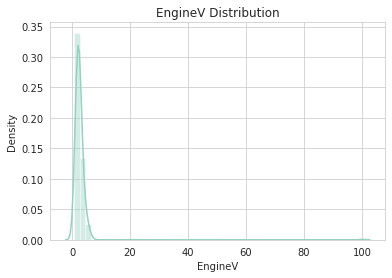

In [22]:
sns.distplot(ndf1['EngineV'])
plt.title('EngineV Distribution');

In [23]:
# let us choose capacity of Engine less than 7L.

ndf5 = ndf4[ndf4['EngineV']<7]

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


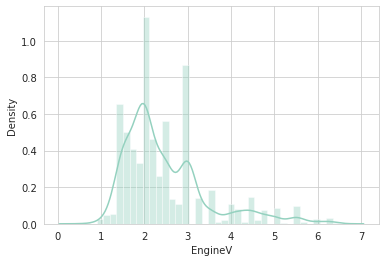

In [24]:
sns.distplot(ndf5['EngineV']);

In [25]:
ndf5

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011
...,...,...,...,...,...,...,...,...
4338,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008
4339,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999


In [26]:
# As u can see the above dataframe index lasts at 4344 row but it shows 3908 rows x 8 columns.
# so we should reset index values.

ndf5_reset = ndf5.reset_index(drop=True)
ndf5_reset

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011
...,...,...,...,...,...,...,...,...
3903,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008
3904,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014
3905,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
3906,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999


In [27]:

# new descriptive analysis
ndf5_reset.describe()

,Price,Mileage,EngineV,Year
count,3908.000000,3908.000000,3908.000000,3908.000000
mean,19964.668401,158.929632,2.475801,2006.798362
std,26046.690402,96.230380,0.980810,6.126537
min,800.000000,0.000000,0.600000,1988.000000
25%,7286.750000,89.750000,1.800000,2003.000000
50%,11800.000000,155.500000,2.200000,2008.000000
75%,22000.000000,225.000000,3.000000,2012.000000
max,300000.000000,433.000000,6.500000,2016.000000


In [28]:
# out starting descriptive analysis
ndf1.describe()

,Price,Mileage,EngineV,Year
count,4025.000000,4025.000000,4025.000000,4025.000000
mean,19552.308065,163.572174,2.764586,2006.379627
std,25815.734988,103.394703,4.935941,6.695595
min,600.000000,0.000000,0.600000,1969.000000
25%,6999.000000,90.000000,1.800000,2003.000000
50%,11500.000000,158.000000,2.200000,2007.000000
75%,21900.000000,230.000000,3.000000,2012.000000
max,300000.000000,980.000000,99.990000,2016.000000


### Linearity of the model
Fitting a linear model to data with non-linear patterns results in serious prediction errors, especially out-of-sample. 

Now we have to scatter plot to check the linearity between
#### price->year,mileage,enginev

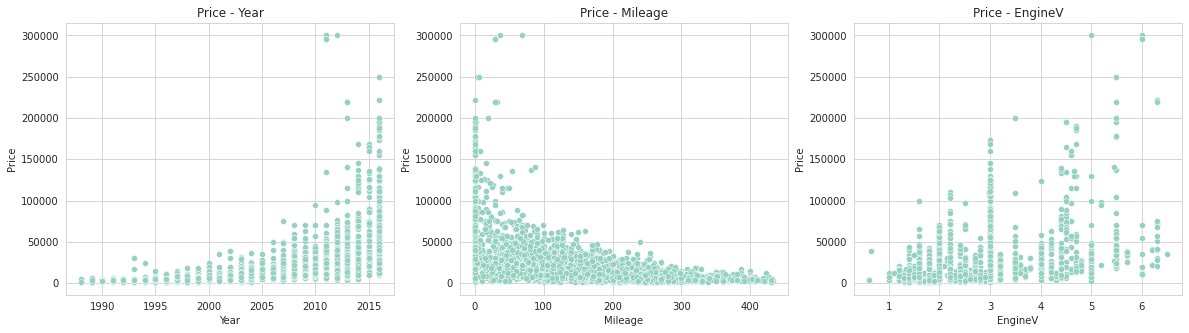

In [29]:
plt.figure(figsize=[20,5])
plt.subplot(1,3,1)
plt.title("Price - Year");
sns.scatterplot(x='Year',y='Price',data = ndf5_reset );

plt.subplot(1,3,2)
plt.title("Price - Mileage");
sns.scatterplot(y='Price',x='Mileage',data=ndf5_reset);

plt.subplot(1,3,3)
plt.title("Price - EngineV");
sns.scatterplot(y='Price',x='EngineV',data=ndf5_reset);

### From above plot we can see they are not perfect linear .  Here price is not normally distributed.

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


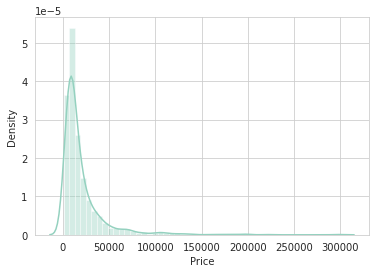

In [30]:
sns.distplot(ndf5['Price']);

In [31]:
ndf5_reset

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011
...,...,...,...,...,...,...,...,...
3903,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008
3904,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014
3905,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014
3906,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999


### from above plot at top we can see le-5 i.e. log transformation to deal such kind of problem.


In [32]:
price1 = np.log(ndf5_reset['Price'])

# Now add price1 to ndf5_reset dataframe.....
ndf5_reset['Log_Price'] = price1
ndf5_reset

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Log_Price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,9.814656
...,...,...,...,...,...,...,...,...,...
3903,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008,9.350102
3904,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014,9.792556
3905,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,11.736069
3906,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,8.779557


In [33]:
ndf5_reset.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Log_Price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,9.814656


### Now let's scatter plot these with log_prcie

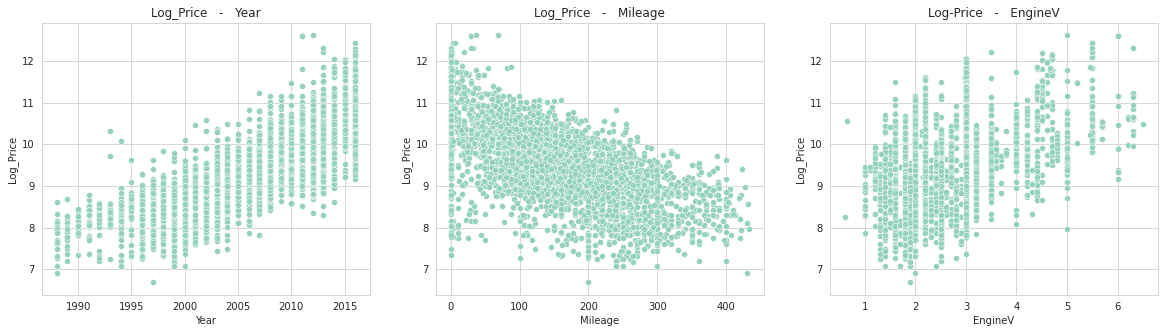

In [34]:
plt.figure(figsize=[20,5])
plt.subplot(1,3,1)
plt.title("Log_Price   -   Year");
sns.scatterplot(x='Year',y='Log_Price',data=ndf5_reset);

plt.subplot(1,3,2)
plt.title("Log_Price   -   Mileage");
sns.scatterplot(x='Mileage',y='Log_Price',data=ndf5_reset);

plt.subplot(1,3,3)
plt.title("Log-Price   -   EngineV");
sns.scatterplot(x='EngineV',y='Log_Price',data=ndf5_reset);

In [35]:
# since we have log_price values we can drop unnecessary column of price.

ndf5_reset = ndf5_reset.drop('Price',axis=1)

In [36]:
ndf5_reset["Registration"].replace(('yes','no'),(1,0),inplace=True)
ndf5_reset

,Brand,Body,Mileage,EngineV,Engine Type,Registration,Year,Log_Price
0,BMW,sedan,277,2.0,Petrol,1,1991,8.342840
1,Mercedes-Benz,van,427,2.9,Diesel,1,1999,8.974618
2,Mercedes-Benz,sedan,358,5.0,Gas,1,2003,9.495519
3,Audi,crossover,240,4.2,Petrol,1,2007,10.043249
4,Toyota,crossover,120,2.0,Petrol,1,2011,9.814656
...,...,...,...,...,...,...,...,...
3903,Volkswagen,van,163,2.5,Diesel,1,2008,9.350102
3904,Toyota,sedan,35,1.6,Petrol,1,2014,9.792556
3905,Mercedes-Benz,sedan,9,3.0,Diesel,1,2014,11.736069
3906,BMW,sedan,1,3.5,Petrol,1,1999,8.779557


## Checking Multicollinearity using Variance inflation factor(VIF) 
## VIF=1/{1-R^2}

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
var = ndf5_reset[['Mileage','Year','EngineV']]
vif_df = pd.DataFrame()
vif_df["VIF"] = [variance_inflation_factor(var.values,i) for i in range(var.shape[1])]
vif_df["Features"] = var.columns
vif_df

,VIF,Features
0,3.703955,Mileage
1,10.302420,Year
2,7.379696,EngineV


## Fix the Multicollinearity

In [38]:
# To fix this we should drop high vif column i.e. Year
nan_multicollinearity = ndf5_reset.drop('Year',axis=1)
nan_multicollinearity

,Brand,Body,Mileage,EngineV,Engine Type,Registration,Log_Price
0,BMW,sedan,277,2.0,Petrol,1,8.342840
1,Mercedes-Benz,van,427,2.9,Diesel,1,8.974618
2,Mercedes-Benz,sedan,358,5.0,Gas,1,9.495519
3,Audi,crossover,240,4.2,Petrol,1,10.043249
4,Toyota,crossover,120,2.0,Petrol,1,9.814656
...,...,...,...,...,...,...,...
3903,Volkswagen,van,163,2.5,Diesel,1,9.350102
3904,Toyota,sedan,35,1.6,Petrol,1,9.792556
3905,Mercedes-Benz,sedan,9,3.0,Diesel,1,11.736069
3906,BMW,sedan,1,3.5,Petrol,1,8.779557


## Feature Selection

###### Feature selection is a way of selecting the subset of the most relevant features from the original features set by removing the redundant ..

In [39]:
from sklearn.preprocessing import LabelEncoder
temp = nan_multicollinearity.copy()
for col in temp.columns:
  if(temp[col].dtypes == 'object'):
    enc = LabelEncoder()
    temp[col] = enc.fit_transform(temp[col])

# correleated Features with target var
print(abs(temp.corrwith(temp['Log_Price'])).sort_values(ascending=False))    

Log_Price       1.000000
Mileage         0.625615
EngineV         0.453800
Registration    0.451268
Body            0.391312
Brand           0.109288
Engine Type     0.040752
dtype: float64


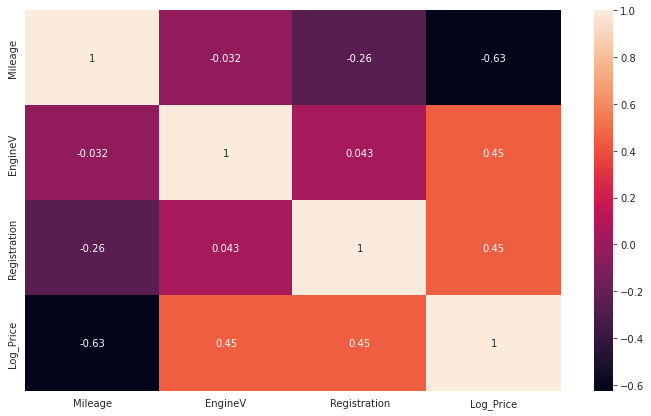

In [40]:
# heat map
plt.figure(figsize=[12,7])
sns.heatmap(nan_multicollinearity.corr(),annot=True);

#### Higher the score more relevant is feature towards out target var.


In [41]:
from sklearn.ensemble import ExtraTreesRegressor
x = temp.drop('Log_Price',axis=1)
y = temp['Log_Price']
ETR = ExtraTreesRegressor()
ETR.fit(x,y)

ExtraTreesRegressor()

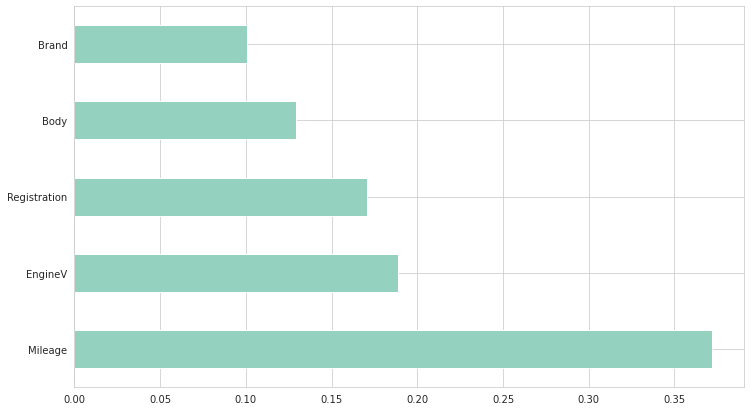

In [42]:
plt.figure(figsize=[12,7])
feature_imp = pd.Series(ETR.feature_importances_,index=x.columns)
feature_imp.nlargest(5).plot(kind="barh")  # for horizontal
plt.show();

In [44]:
print(feature_imp.sort_values(ascending=False))         # Descending order.......

Mileage         0.372005
EngineV         0.188583
Registration    0.170759
Body            0.129307
Brand           0.100408
Engine Type     0.038938
dtype: float64


## Categorical Features.....

In [46]:
# by creating dummy values and develop the model..

dummies = pd.get_dummies(nan_multicollinearity,drop_first=True)
dummies.head()


,Mileage,EngineV,Registration,Log_Price,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol
0,277,2.0,1,8.342840,1,0,0,0,0,0,0,0,1,0,0,0,0,1
1,427,2.9,1,8.974618,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2,358,5.0,1,9.495519,0,1,0,0,0,0,0,0,1,0,0,1,0,0
3,240,4.2,1,10.043249,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,120,2.0,1,9.814656,0,0,0,0,1,0,0,0,0,0,0,0,0,1


## Model Development

### by using simple linear regression model declares dependent and independent variable...

In [52]:
x = dummies.drop('Log_Price',axis=1)
y = dummies['Log_Price']


## Feature scaling using standard scaler.........


In [53]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss

StandardScaler()

In [54]:
ss.fit(x[['Mileage','EngineV']])

StandardScaler()

In [58]:
scaled_input = ss.transform(x[['Mileage','EngineV']])
scaled_data = pd.DataFrame(scaled_input,columns=['Mileage','EngineV'])
# scaled_input
# scaled_data

In [61]:
scaled_input2 = scaled_data.join(x.drop(['Mileage','EngineV'],axis=1))
# scaled_input2

## Training and Testing Data

In [62]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(scaled_input2,y,test_size = 0.3)


### LINEAR REGRESSION MODEL

In [63]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [71]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

r_square = r2_score(y_test,y_pred)
mse = np.sqrt(mean_squared_error(y_test,y_pred))

print("r2-score : ",r_square)
print("Root Mean squared error : ",mse)

r2-score :  0.7620553405405976
Root Mean squared error :  0.43455224403589193


### RANDOM FOREST REGRESSION MODEL

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(x_train,y_train)

y_pred1 = rf.predict(x_test)

r_square1 = r2_score(y_test,y_pred1)
mse1 = np.sqrt(mean_squared_error(y_test,y_pred1))

print("r2-score : ",r_square1)
print("Root Mean squared error : ",mse1)

r2-score :  0.7893350000797613
Root Mean squared error :  0.4088840878459428


### GBT REGRESSION MODEL

### gradientboosting helps to build an additive model which used for optimizing the problem  ----  INTERNET

In [75]:
from sklearn.ensemble import GradientBoostingRegressor

rf = GradientBoostingRegressor()

rf.fit(x_train,y_train)

y_pred2 = rf.predict(x_test)

r_square2 = r2_score(y_test,y_pred2)
mse2 = np.sqrt(mean_squared_error(y_test,y_pred2))

print("r2-score : ",r_square2)
print("Root Mean squared error : ",mse2)

r2-score :  0.7908970630842729
Root Mean squared error :  0.40736534695748977


In [77]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_squared_error

print("Mean-squared-error : ", mean_squared_error(y_test,y_pred2))
print("Mean-absolute-error : ", mean_absolute_error(y_test,y_pred2))
print("Root Mean-squared-error : ", np.sqrt(mean_squared_error(y_test,y_pred2)))

Mean-squared-error :  0.16594652590179604
Mean-absolute-error :  0.2992669206017247
Root Mean-squared-error :  0.40736534695748977


### FROM ABOVE THREE MODELS 
### ---> LRM
### ---> RFR
### ---> GBT

### <----->GBT gives better accuracy

In [79]:
##  LET'S CHECK PREDICTIONS OF PRICE MANUALLY.....


# predicted price----

df = pd.DataFrame(np.exp(y_pred2),columns=["Predicted Price"])

##  actual price------

y_test = y_test.reset_index(drop=True)
df["Actual Price"] = np.exp(y_test)


## Difference between predicted and actual price-----

df['Difference'] = df['Actual Price'] - df['Predicted Price']

## Difference percentage....

df['Difference (%)'] = np.absolute(df['Difference']/df['Actual Price'])*100

pd.set_option('display.float_format',lambda x: '%.2f' %x)
df.sort_values(['Difference (%)'])

df

,Predicted Price,Actual Price,Difference,Difference (%)
0,28484.52,22000.00,-6484.52,29.48
1,4181.08,6100.00,1918.92,31.46
2,58832.61,62999.00,4166.39,6.61
3,7219.37,7500.00,280.63,3.74
4,7980.67,8800.00,819.33,9.31
...,...,...,...,...
1168,25285.63,22700.00,-2585.63,11.39
1169,9262.58,12090.00,2827.42,23.39
1170,46043.69,38233.00,-7810.69,20.43
1171,87477.58,74500.00,-12977.58,17.42


In [80]:
df.head()

,Predicted Price,Actual Price,Difference,Difference (%)
0,28484.52,22000.00,-6484.52,29.48
1,4181.08,6100.00,1918.92,31.46
2,58832.61,62999.00,4166.39,6.61
3,7219.37,7500.00,280.63,3.74
4,7980.67,8800.00,819.33,9.31


In [81]:
df.tail()

,Predicted Price,Actual Price,Difference,Difference (%)
1168,25285.63,22700.00,-2585.63,11.39
1169,9262.58,12090.00,2827.42,23.39
1170,46043.69,38233.00,-7810.69,20.43
1171,87477.58,74500.00,-12977.58,17.42
1172,7541.83,7300.00,-241.83,3.31
